## Problem 12.1 - Handwritten Digit Classification

In [1]:
# load the handwritten digits dataset
import urllib.request
import gzip
import shutil
import pandas as pd
urllib.request.urlretrieve("https://hastie.su.domains/ElemStatLearn/datasets/zip.train.gz", filename = './digits_train')
urllib.request.urlretrieve("https://hastie.su.domains/ElemStatLearn/datasets/zip.test.gz", filename = './digits_test')
with gzip.open('digits_train', 'rb') as f_in:
    with open('digits_train.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
        
with gzip.open('digits_test', 'rb') as f_in:
    with open('digits_test.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)  
        
# Load into data frame
data_train = pd.read_csv('digits_train.txt', header = None, delimiter = ' ')
data_test = pd.read_csv('digits_test.txt', header = None, delimiter = ' ')

# Extract features x and labels y
x_train = data_train.iloc[:, 1:-1].values # Training data has one column of NaN entries
y_train = data_train.iloc[:, 0].values

x_test = data_test.iloc[:, 1:].values
y_test = data_test.iloc[:, 0].values 

In [2]:
# choose device such that we can train on GPU if available
import torch
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'

In [3]:
# initialize data as torch tensors 
X_train = torch.from_numpy(x_train.reshape(x_train.shape[0], 1, 16, 16)).float().to(device)
Y_train = torch.from_numpy(y_train.reshape(x_train.shape[0])).long().to(device)

In [35]:
# define the architecture of the neural network
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels = 1,
                out_channels = 16,
                kernel_size = 5,
                stride = 1,
                padding = 2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.out = nn.Linear(32 * 4 * 4, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)           # flatten the output of conv2
        output = self.out(x)
        return output
    
# create an instance of the neural network
cnn = CNN().to(device)

# TODO: simpler architecture

In [36]:
# define a loss function and optimizer for training the cnn
loss_func = nn.CrossEntropyLoss()
pars = cnn.parameters()
optimizer = torch.optim.SGD(pars, lr = 0.05, weight_decay = 0, momentum = 0.9)

# TODO: experiment with different values

In [50]:
# train the model 
cnn.train()
n_epochs = 500
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    outputs = cnn(X_train)
    loss = loss_func(outputs, Y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

In [38]:
import numpy as np
import matplotlib.pyplot as plt

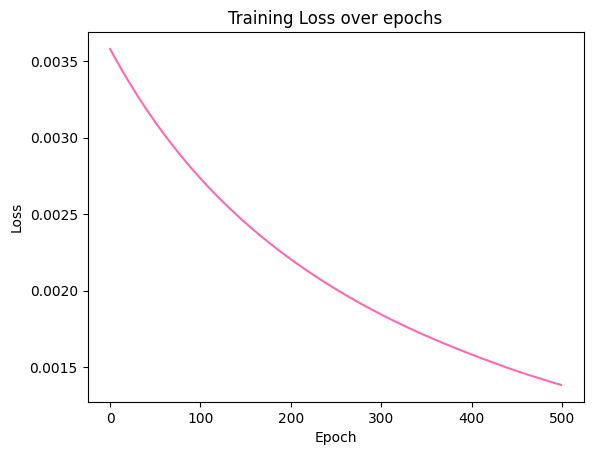

In [51]:
plt.figure()
plt.plot(losses, color = 'hotpink')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over epochs")
plt.show()

In [41]:
# create tensor for the test data
X_test = torch.from_numpy(x_test.reshape(x_test.shape[0], 1, 16, 16)).float().to(device)

In [52]:
# switch to evaluation model and test the model
cnn.eval()

with torch.no_grad():
    outputs = cnn(X_test)
    probabilities = torch.softmax(outputs, dim = 1)
    predictions = torch.argmax(probabilities, dim = 1)

accuracy = (predictions == y_test).float().mean().item()
print(f"Test Accuracy: {accuracy * 100:.2f} %")

Test Accuracy: 95.57 %


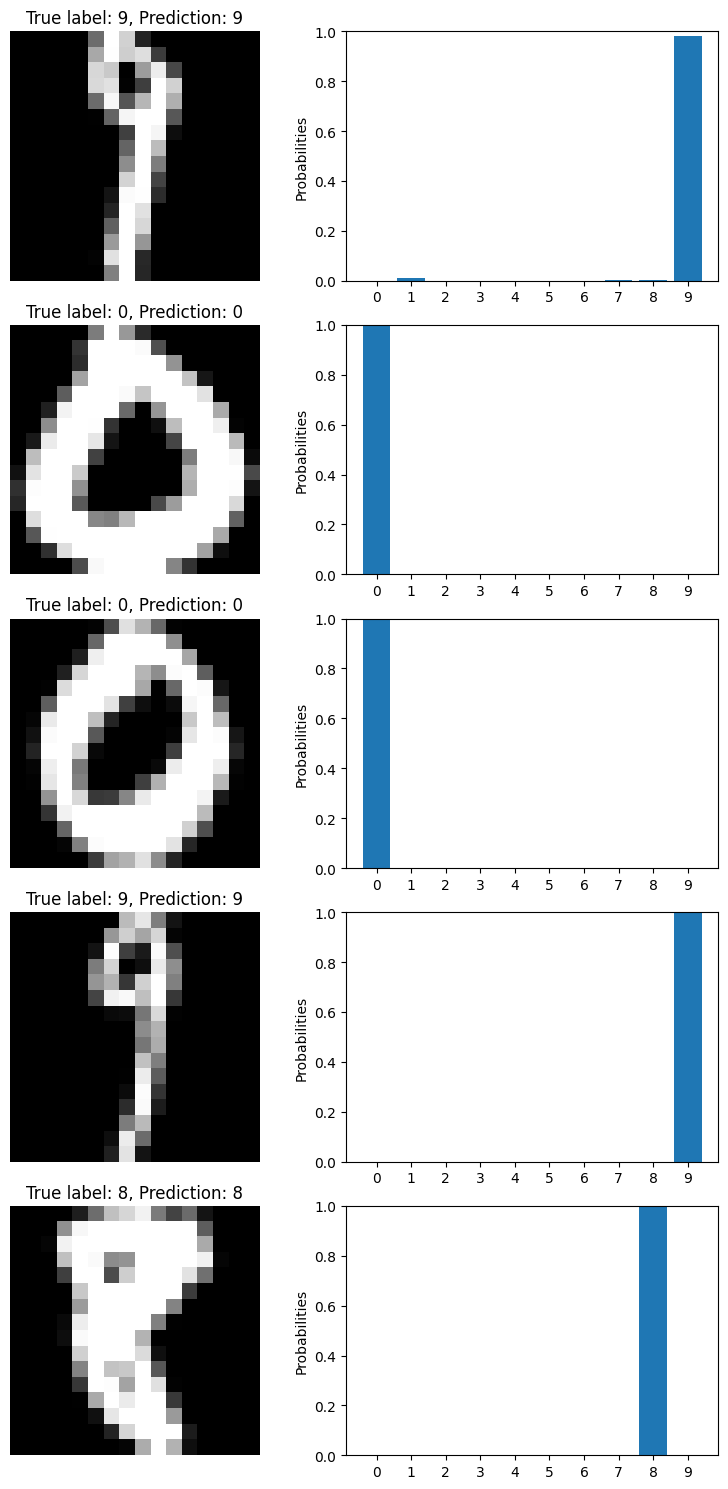

In [ ]:
n_examples = 5
indices = np.random.choice(len(X_test), n_examples, replace = False)

cnn.eval()
with torch.no_grad():
    outputs = cnn(X_test[indices])
    prob_ex = torch.softmax(outputs, dim = 1)
    pred_ex = torch.argmax(prob_ex, dim = 1)
    true_labels = y_test[indices]

fig, axes = plt.subplots(n_examples, 2, figsize = (8, 3 * n_examples))

for i in range(n_examples):
    axes[i, 0].imshow(X_test[indices[i]].cpu().squeeze(), cmap = "gray")
    axes[i, 0].set_title(f"True label: {true_labels[i]}, Prediction: {pred_ex[i]}")
    axes[i, 0].axis("off")

    axes[i, 1].bar(range(10), prob_ex[i])
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_xticks(range(10))
    axes[i, 1].set_ylabel("Probabilities")

plt.tight_layout()
plt.show()
